<a href="https://colab.research.google.com/github/03sarath/gcp-Imagen3-Gemini/blob/main/gcp_video_generation_and_Nano%20Banana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Copyright 2025 Psitron Technologies

# Veo 2 & 3 Video Generation

## Overview

### Veo 2

Veo 2 on Vertex AI brings Google's state of the art video generation capabilities to application developers. It's capable of creating videos with astonishing detail that simulate real-world physics across a wide range of visual styles.

In this tutorial, you will learn how to use the Google Gen AI SDK for Python to interact with Veo 2 and generate new videos from text prompts and input images.

## Get started

### Install Google Gen AI SDK for Python and other libraries

In [1]:
%pip install --upgrade --quiet google-genai
%pip install -q mediapy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.1/259.1 kB 8.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.56.3 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 30.5 MB/s eta 0:00:00


### Authenticate your notebook environment (Colab only)

If you are running this notebook on Google Colab, run the following cell to authenticate your environment.

### Generate videos from a text prompt

With Veo 2 or 3,3.1 or Omni, you have the option to generate 8 second videos from a text prompt. In order to generate a video in the following sample, specify the following info:
- **Prompt:** A detailed description of the video you would like to see.
- **Aspect ratio:** Select either 16:9 or 9:16.
- **File location:** The generated video will be shown below with support from a previously defined helper function. The video will also be stored in Cloud Storage once video generation is complete. Specify the file path where you would like this video to be stored in the output_gcs field.
- **Number of videos:** Set this value to 1 or 2.
- **Video duration:** Can 5, 6, 7, or 8 seconds.
- **Prompt enhancement:** The `veo-2.0-generate-001` model offers the option to enhance your provided prompt. To utilize this feature, set `enhance_prompt` to True. A new, detailed prompt will be created from your original one to help generate higher quality videos that better adhere to your prompt's intent.

### Getting started with  Veo 3

In [13]:
import time
from google import genai
from google.genai import types

client = genai.Client(api_key='your-key')

prompt = """
Create an **8-second cinematic video**.

A dramatic, visually captivating scene unfolds naturally in **one continuous shot**. Begin with a visually intriguing close-up that immediately establishes the subject. The camera slowly moves forward, revealing more of the environment and building anticipation. As the camera reaches the subject, a subtle but unexpected visual event occurs, creating a strong cinematic payoff in the final moments.

**Visual style:** photorealistic, premium cinematic filmmaking, natural textures, realistic physics, sophisticated lighting, detailed environment, subtle atmospheric depth, realistic shadows and reflections.

**Camera:** cinematic camera movement, smooth controlled dolly-in, natural depth of field, realistic lens characteristics, carefully composed framing.

**Lighting:** dramatic but realistic lighting with natural highlights, soft shadows and atmospheric depth.

**Action:** clear, believable movement with a beginning, development and payoff within the 8-second duration.

**Audio:** natural environmental ambience, realistic synchronized sound effects, subtle cinematic tension that builds toward the final moment.

**Duration:** exactly 8 seconds.

**Shot:** one continuous shot, no scene cuts, no abrupt transitions.

Make the result feel like a **professionally produced cinematic film sequence**, not a social-media advertisement or short-form video.

"""

operation = client.models.generate_videos(
    model="veo-3.1-generate-preview", #veo-3.1-generate-preview ,veo-3.0-generate-preview
    prompt=prompt,
)

# Poll the operation status until the video is ready.
while not operation.done:
    print("Waiting for video generation to complete...")
    time.sleep(10)
    operation = client.operations.get(operation)

# Download the generated video.
generated_video = operation.response.generated_videos[0]
client.files.download(file=generated_video.video)
generated_video.video.save("dialogue_example.mp4")
print("Generated video saved to dialogue_example.mp4")

Waiting for video generation to complete...
Waiting for video generation to complete...
Waiting for video generation to complete...
Waiting for video generation to complete...
Waiting for video generation to complete...
Waiting for video generation to complete...
Generated video saved to dialogue_example.mp4


# Nano Banana (Image generation)


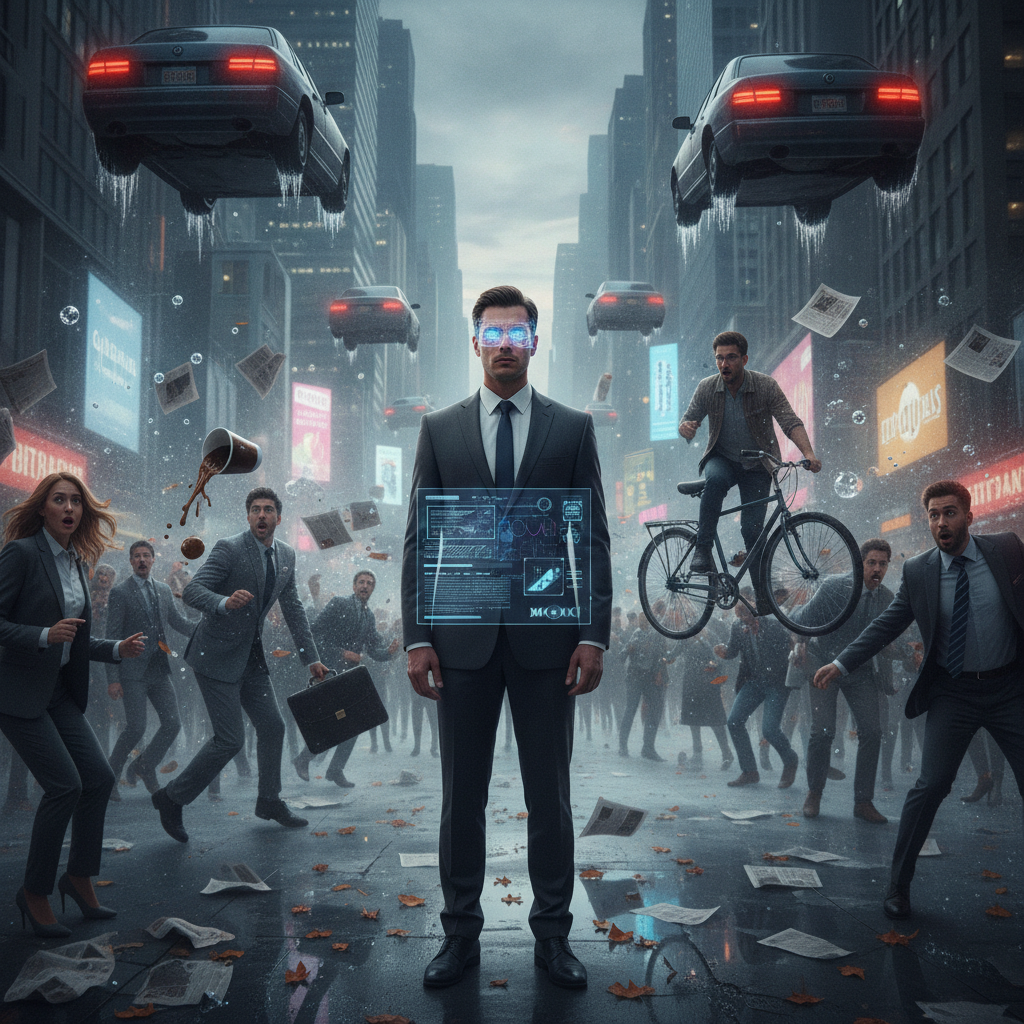

In [16]:
from google import genai
from PIL import Image

client = genai.Client(api_key='your-key')

response = client.models.generate_content(
    model="gemini-2.5-flash-image",
    contents="A businessman standing completely still in the middle of a busy city while everything around him is frozen in mid-air — flying cars, coffee droplets, papers and people suspended in motion — with one glowing AI interface reflected in his eyes.",
)

for part in response.parts:
    if part.inline_data:
        image = part.as_image()
        image.show()